In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
from torch import nn
from torch.utils.data import DataLoader
import copy
from modules import func, networks
import math

In [2]:
#for lenet
BATCH_SIZE = 60
MAX_ITERS = 50000
LAMBDA = 1.3e-3
HIDDENLAYER1 = 300
HIDDENLAYER2 = 100
OUT = 10
VALSIZE=5000
P = 0.2
ROUNDS = 15

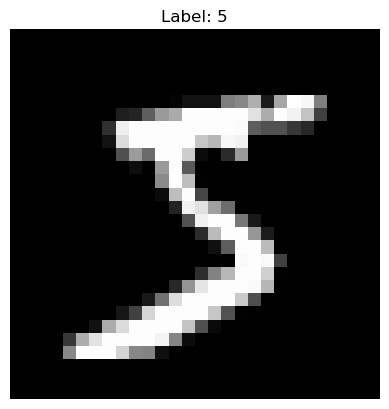

In [3]:
data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

image, label = data[0]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

In [4]:
targets = data.targets.numpy()
idx = list(range(len(data)))

train_idx, val_idx = train_test_split(
    idx,
    test_size=VALSIZE,
    stratify=targets,
    random_state=42,
    shuffle=True
)

train_data = Subset(data, train_idx)
val_data = Subset(data, val_idx)

In [5]:
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(device)

batch_size = BATCH_SIZE

train_dataloader = DataLoader(train_data, batch_size=batch_size)
val_dataloader = DataLoader(val_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)


mps


In [6]:
x, y = train_data[0]
inputsize = math.prod(x.shape)
model = networks.Lenet(inputsize, HIDDENLAYER1, HIDDENLAYER2, OUT).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LAMBDA)

In [7]:
linear_layers = [(i, m) for i, m in enumerate(model.linear_relu_stack) if isinstance(m, nn.Linear)]

original = [[layer.weight.data.clone(), layer.bias.data.clone()] 
         for _, layer in linear_layers]

out = []

MAX_ITERS=5000

for i in range(ROUNDS):

    bestIter = networks.trainEarlyStop(train_dataloader, val_dataloader, model, loss_fn, optimizer, device, MAX_ITERS)
    a = networks.test(test_dataloader, model, loss_fn, device)

    out.append((bestIter, a))

    layers = [(i, m) for i, m in enumerate(model.linear_relu_stack) if isinstance(m, nn.Linear)]
    saved = [[layer.weight.data.clone(), layer.bias.data.clone()] for _, layer in layers]

    w = func.leastweightRank(saved, 5)
    func.removeNodes(original, w[:int(len(w)*P)])

    hl1 = original[1][0].shape[0]
    hl2 = original[2][0].shape[0]

    model = networks.Lenet(inputsize, hl1, hl2, OUT).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LAMBDA)
    new_linear_layers = [(i, m) for i, m in enumerate(model.linear_relu_stack) if isinstance(m, nn.Linear)]

    for (w, b), (_, layer) in zip(original, new_linear_layers):
        layer.weight.data = w.clone()
        layer.bias.data   = b.clone()

Test Error: 
 Accuracy: 97.2%, Avg loss: 0.090901 

Test Error: 
 Accuracy: 97.0%, Avg loss: 0.093475 

Test Error: 
 Accuracy: 97.0%, Avg loss: 0.097164 

Test Error: 
 Accuracy: 97.4%, Avg loss: 0.086585 

Test Error: 
 Accuracy: 97.0%, Avg loss: 0.093205 

Test Error: 
 Accuracy: 96.8%, Avg loss: 0.106038 

Test Error: 
 Accuracy: 96.7%, Avg loss: 0.115667 

Test Error: 
 Accuracy: 95.9%, Avg loss: 0.137502 

Test Error: 
 Accuracy: 94.7%, Avg loss: 0.178694 

Test Error: 
 Accuracy: 94.1%, Avg loss: 0.209220 

Test Error: 
 Accuracy: 89.3%, Avg loss: 0.364418 

Test Error: 
 Accuracy: 87.6%, Avg loss: 0.416989 

Test Error: 
 Accuracy: 89.4%, Avg loss: 0.350620 

Test Error: 
 Accuracy: 87.2%, Avg loss: 0.432024 

Test Error: 
 Accuracy: 89.6%, Avg loss: 0.358764 



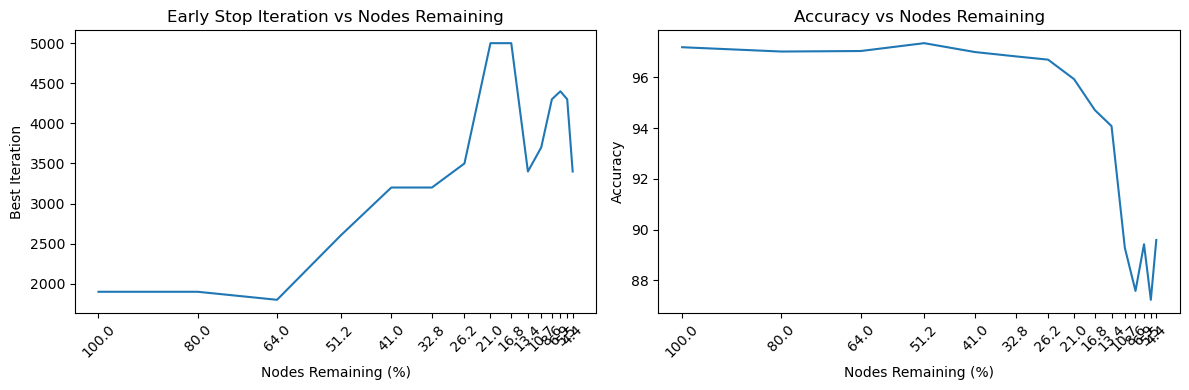

In [8]:
remaining = [100 * (1 - P) ** i for i in range(len(out))]

iters = [x[0] for x in out]
accs  = [x[1] for x in out]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(remaining, iters)
ax1.set_xlabel('Nodes Remaining (%)')
ax1.set_ylabel('Best Iteration')
ax1.set_title('Early Stop Iteration vs Nodes Remaining')
ax1.set_xticks(remaining)
ax1.set_xticklabels([f"{r:.1f}" for r in remaining], rotation=45)
ax1.invert_xaxis()

ax2.plot(remaining, accs)
ax2.set_xlabel('Nodes Remaining (%)')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy vs Nodes Remaining')
ax2.set_xticks(remaining)
ax2.set_xticklabels([f"{r:.1f}" for r in remaining], rotation=45)
ax2.invert_xaxis()

plt.tight_layout()
plt.show()


In [ ]:
''''
model.eval()
i = 10
x, y = test_data[i][0], test_data[i][1]
with torch.no_grad():
    x=x.to(device)
    logits = model(x.to(device))
    probs = torch.softmax(logits, dim=1)
    predicted, actual, c = probs[0].argmax(0), y, probs[0]
    print(f'Predicted: "{predicted}", Actual: "{actual}"')
    print(c)
'''

Predicted: "0", Actual: "0"
tensor([1.0000e+00, 1.8123e-16, 3.3264e-12, 1.0189e-16, 1.6449e-14, 2.4744e-16,
        5.7396e-13, 1.0295e-14, 1.6308e-15, 5.3495e-11], device='mps:0')
